**Importing Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Importing Dataset**

In [ ]:
df=pd.read_csv('top50_playlist.csv')
df.head()

,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url
0,18-05-2024,1,Ella Baila Sola,Eslabon Armado,89,165671,album,16,False,https://i.scdn.co/image/ab67616d0000b273dfddf1...
1,18-05-2024,2,Last Night,Morgan Wallen,89,163854,album,36,True,https://i.scdn.co/image/ab67616d0000b273705079...
2,18-05-2024,3,All My Life (feat. J. Cole),Lil Durk & J. Cole,84,223878,single,1,True,https://i.scdn.co/image/ab67616d0000b2737c173b...
3,18-05-2024,4,un x100to,Grupo Frontera & Bad Bunny,99,194563,single,1,False,https://i.scdn.co/image/ab67616d0000b273716c0b...
4,18-05-2024,5,Kill Bill,SZA,94,153946,album,23,False,https://i.scdn.co/image/ab67616d0000b2730c471c...


**Cleaning Dataset**

In [ ]:
df['date']=pd.to_datetime(df['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27800 entries, 0 to 27799
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             27800 non-null  datetime64[ns]
 1   position         27800 non-null  int64         
 2   song             27800 non-null  object        
 3   artist           27800 non-null  object        
 4   popularity       27800 non-null  int64         
 5   duration_ms      27800 non-null  int64         
 6   album_type       27800 non-null  object        
 7   total_tracks     27800 non-null  int64         
 8   is_explicit      27800 non-null  bool          
 9   album_cover_url  27800 non-null  object        
dtypes: bool(1), datetime64[ns](1), int64(4), object(4)
memory usage: 1.9+ MB


/tmp/ipykernel_967/2965284253.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date']=pd.to_datetime(df['date'])


In [ ]:
df.shape

(27800, 10)

In [ ]:
df=df.drop_duplicates(subset=["date","song"])

In [ ]:
#Valid Ranking
df=df[(df['position']>=1) & (df['position']<=50)]

In [ ]:
#standrize artist
df['artist']=df['artist'].str.strip().str.title()
df.head()

,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url
0,2024-05-18,1,Ella Baila Sola,Eslabon Armado,89,165671,album,16,False,https://i.scdn.co/image/ab67616d0000b273dfddf1...
1,2024-05-18,2,Last Night,Morgan Wallen,89,163854,album,36,True,https://i.scdn.co/image/ab67616d0000b273705079...
2,2024-05-18,3,All My Life (feat. J. Cole),Lil Durk & J. Cole,84,223878,single,1,True,https://i.scdn.co/image/ab67616d0000b2737c173b...
3,2024-05-18,4,un x100to,Grupo Frontera & Bad Bunny,99,194563,single,1,False,https://i.scdn.co/image/ab67616d0000b273716c0b...
4,2024-05-18,5,Kill Bill,Sza,94,153946,album,23,False,https://i.scdn.co/image/ab67616d0000b2730c471c...


In [ ]:
#Check Missing Values
df.isnull().sum()


,0
date,0
position,0
song,0
artist,0
popularity,0
duration_ms,0
album_type,0
total_tracks,0
is_explicit,0
album_cover_url,0


**Feature Engineering**

In [ ]:
##days on chart
days_on_chart=df.groupby("song")['date'].nunique()


In [ ]:
##Average Rank
avg_rank=df.groupby("song")['position'].mean()

In [ ]:
##Best rank achieved
best_rank=df.groupby("song")['position'].min()


In [ ]:
##rank volatility index
rank_volatility=df.groupby("song")['position'].std()


In [ ]:
##Popularity trend score
df['popularity_trend']=(df.groupby("song")['popularity'].transform(lambda x: x.rolling(window=7,min_periods=1).mean()))


In [ ]:
##Duration in minutes
df['duration_minutes']=df['duration_ms']/60000

In [ ]:
#Playlist ranking Analysis
##Daily Rank Distribution
daily_rank_distribution=df.groupby("date")['position'].mean()
daily_rank_distribution

,position
date,
2024-05-18,25.5
2024-05-19,25.5
2024-05-20,25.5
2024-05-21,25.5
2024-05-22,25.5
...,...
2025-11-23,25.5
2025-11-24,25.5
2025-11-25,25.5


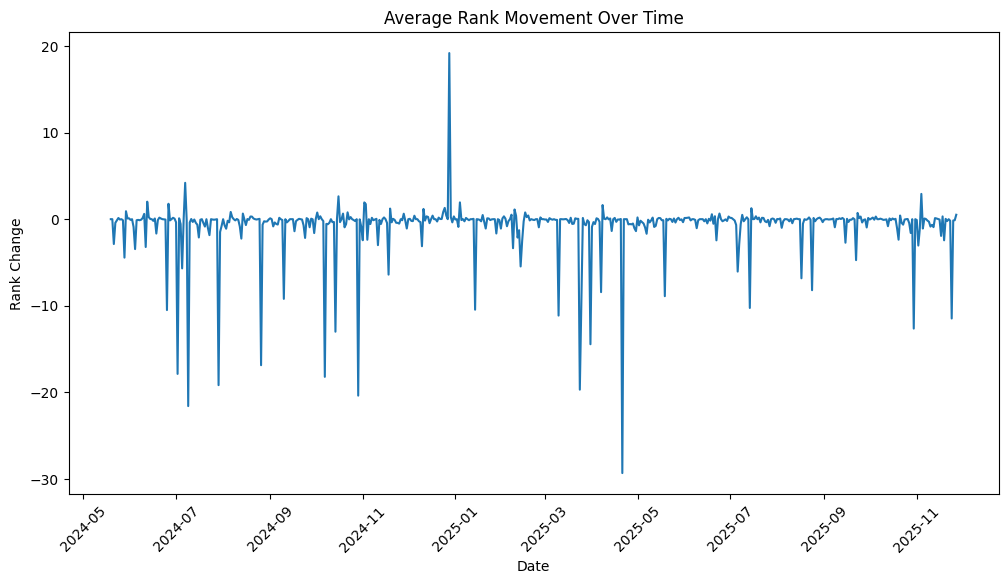

In [ ]:
df=df.sort_values(["song","date"])

df["previous_rank"]=(
    df.groupby("song")["position"]
    .shift()
)

df["rank_change"]=(
    df["previous_rank"]-
    df["position"]
)

movement=(
    df.groupby("date")
    ["rank_change"]
    .mean()
)

plt.figure(figsize=(12,6))

plt.plot(
    movement.index,
    movement.values
)

plt.title("Average Rank Movement Over Time")
plt.xlabel("Date")
plt.ylabel("Rank Change")

plt.xticks(rotation=45)

plt.show()


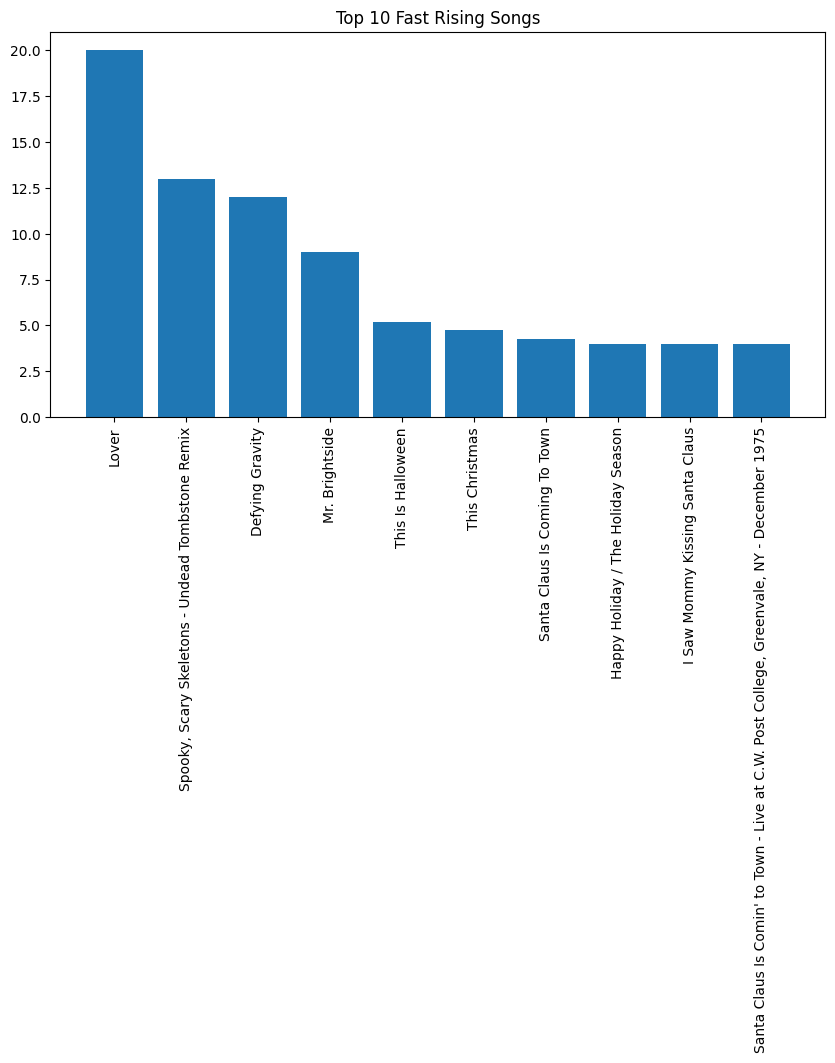

In [ ]:
fast=(
df.groupby("song")
["rank_change"]
.mean()
.nlargest(10)
)

plt.figure(figsize=(10,5))

plt.bar(
    fast.index,
    fast.values
)

plt.title("Top 10 Fast Rising Songs")
plt.xticks(rotation=90)

plt.show()


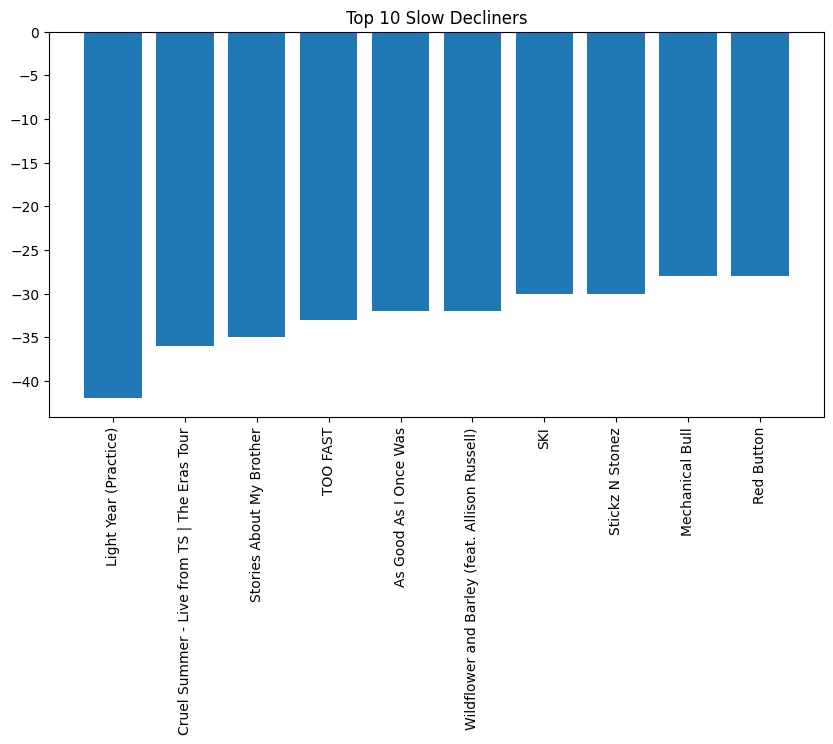

In [ ]:
slow=(
df.groupby("song")
["rank_change"]
.mean()
.nsmallest(10)
)

plt.figure(figsize=(10,5))

plt.bar(
    slow.index,
    slow.values
)

plt.title("Top 10 Slow Decliners")
plt.xticks(rotation=90)

plt.show()

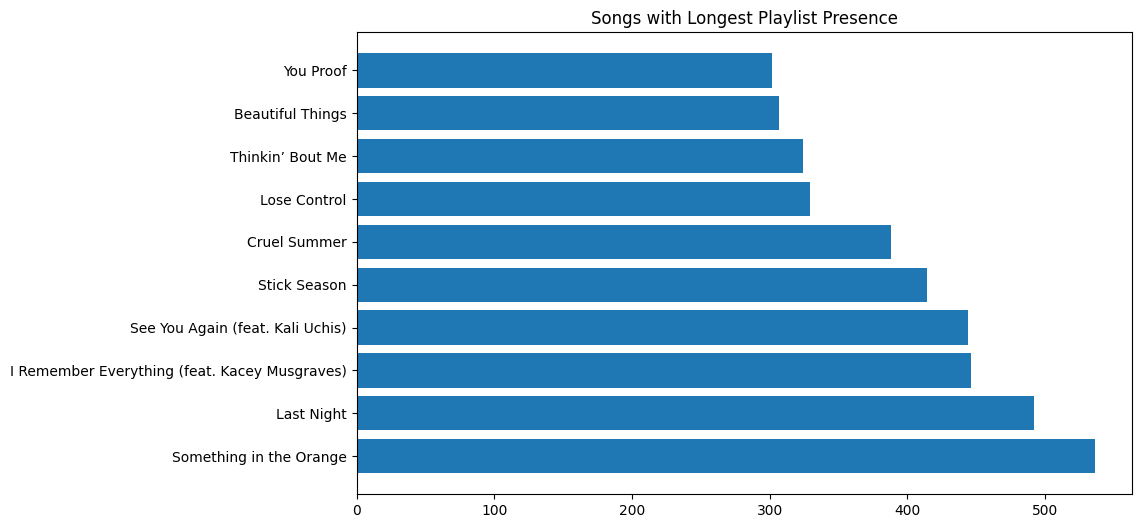

In [ ]:
longest=(
df.groupby("song")
["date"]
.nunique()
.nlargest(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    longest.index,
    longest.values
)

plt.title("Songs with Longest Playlist Presence")

plt.show()

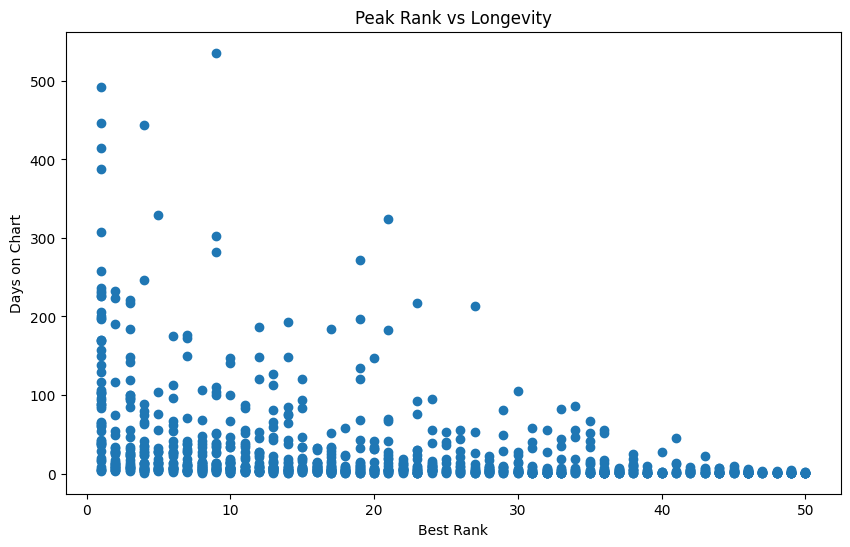

In [ ]:
peak=(
df.groupby("song")
.agg(
best_rank=("position","min"),
days=("date","nunique")
)
)

plt.figure(figsize=(10,6))

plt.scatter(
peak["best_rank"],
peak["days"]
)

plt.title("Peak Rank vs Longevity")
plt.xlabel("Best Rank")
plt.ylabel("Days on Chart")

plt.show()

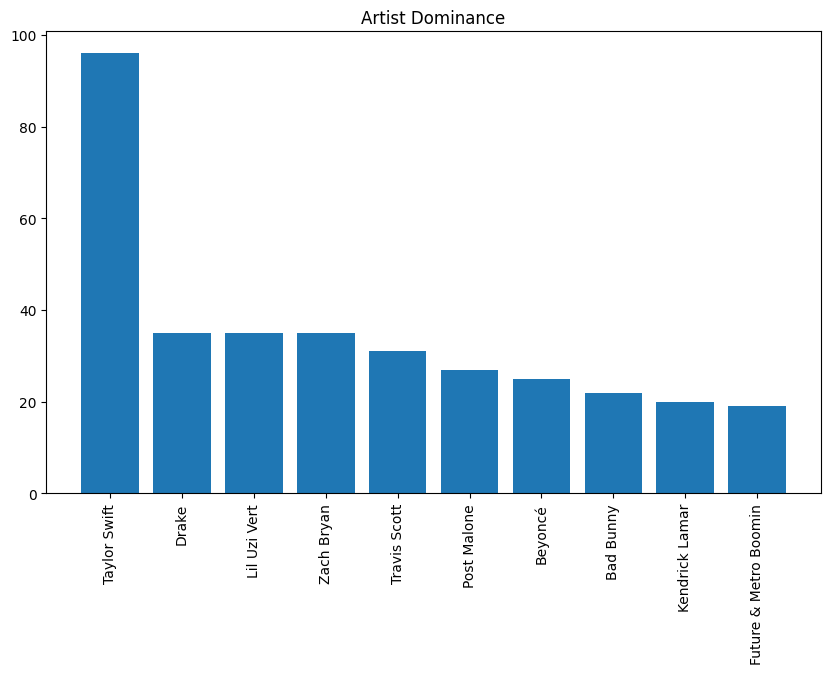

In [ ]:
artist=(
df.groupby("artist")
["song"]
.nunique()
.nlargest(10)
)

plt.figure(figsize=(10,6))

plt.bar(
artist.index,
artist.values
)

plt.xticks(rotation=90)

plt.title("Artist Dominance")

plt.show()

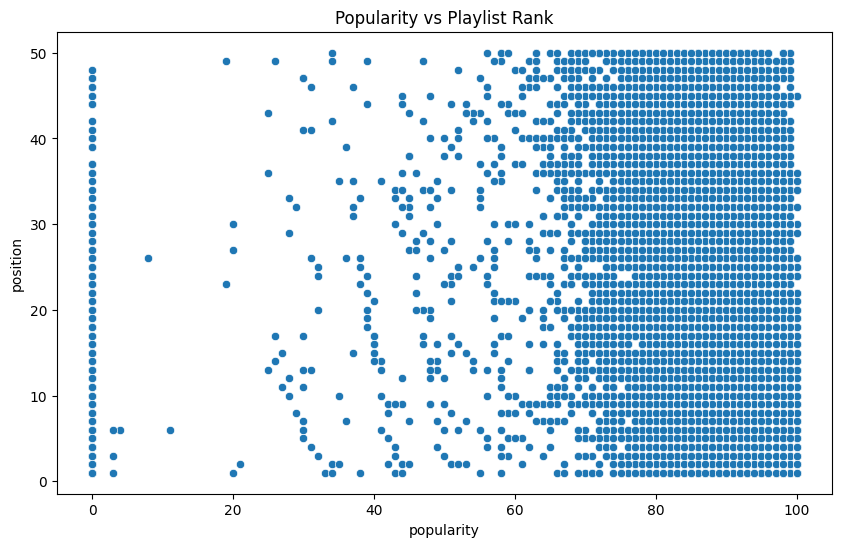

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
x=df["popularity"],
y=df["position"]
)

plt.title("Popularity vs Playlist Rank")

plt.show()

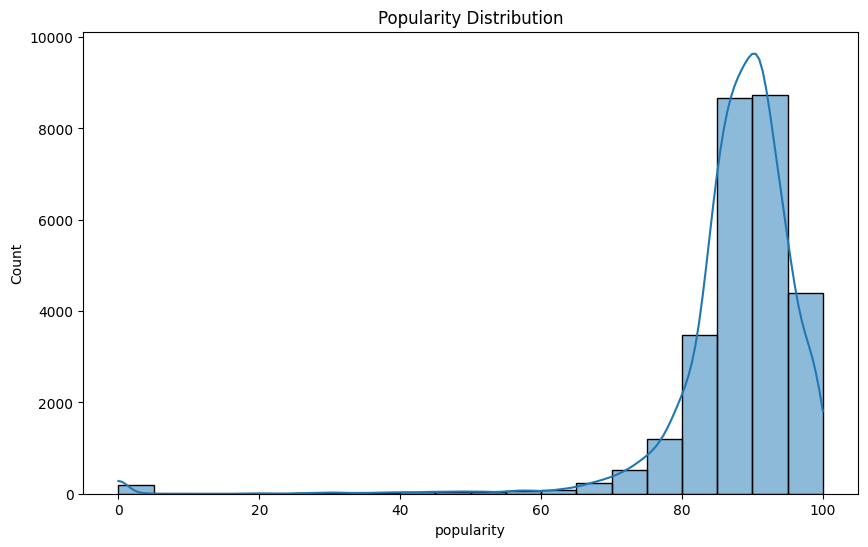

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
df["popularity"],
bins=20,
kde=True
)

plt.title("Popularity Distribution")

plt.show()

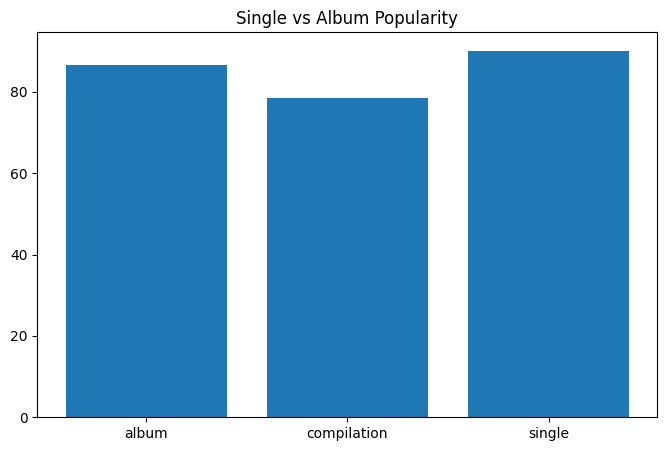

In [ ]:
album=(
df.groupby("album_type")
["popularity"]
.mean()
)

plt.figure(figsize=(8,5))

plt.bar(
album.index,
album.values
)

plt.title(
"Single vs Album Popularity"
)

plt.show()

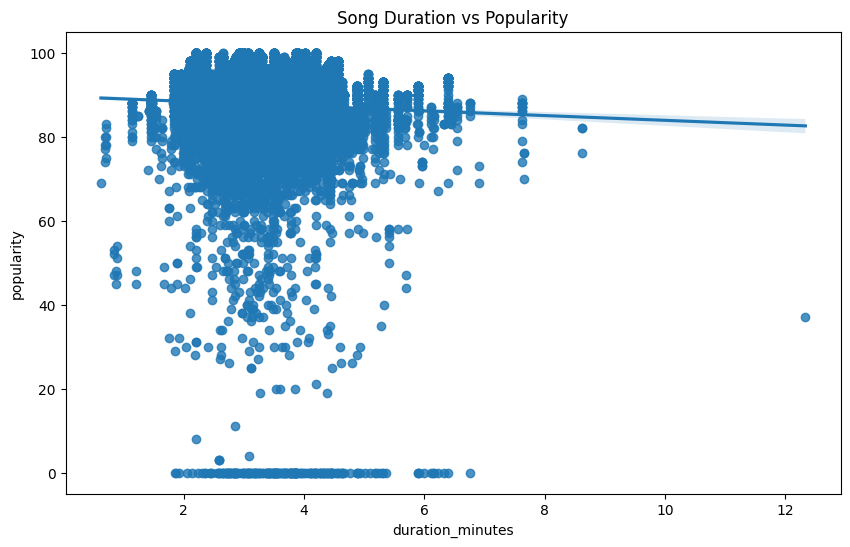

In [ ]:
plt.figure(figsize=(10,6))

sns.regplot(
x=df["duration_minutes"],
y=df["popularity"]
)

plt.title(
"Song Duration vs Popularity"
)

plt.show()

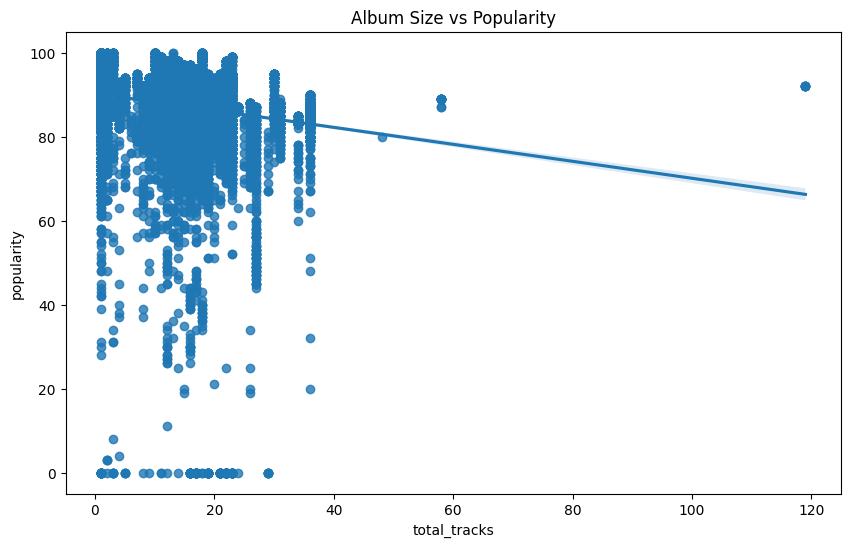

In [ ]:
plt.figure(figsize=(10,6))

sns.regplot(
x=df["total_tracks"],
y=df["popularity"]
)

plt.title(
"Album Size vs Popularity"
)

plt.show()


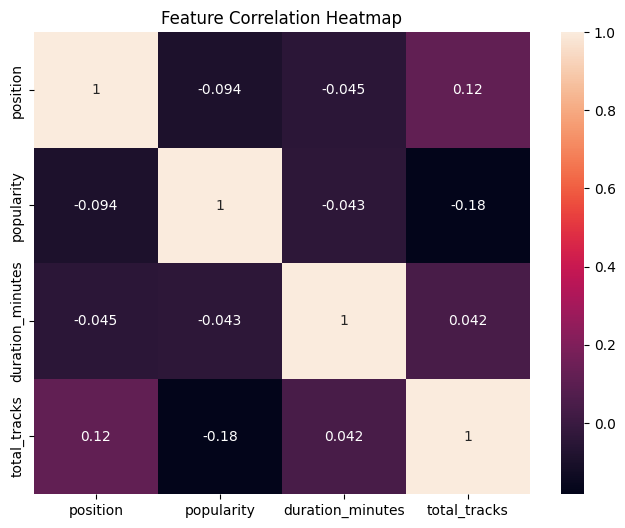

In [ ]:
corr=(
df[
[
"position",
"popularity",
"duration_minutes",
"total_tracks"
]
].corr()
)

plt.figure(figsize=(8,6))

sns.heatmap(
corr,
annot=True
)

plt.title(
"Feature Correlation Heatmap"
)

plt.show()